# Sprint 4 — Tier 1 Ensemble Maximisation (no retraining)

**Project:** Q-INTERVAL-Lite+ | **Author:** Pasindu Pahasara (104348348)

## What this does
Extracts everything available from the models that **already exist**, before spending GPU time on retraining.

Sprint 3 final ensemble was **v4 + v5 + mammofm** → 0.7395 acc / 0.7385 macro F1 / 0.7611 mal recall / 0.8914 AUC.

Two problems with it:
1. **v4 and v5 are both ResNet-101** — correlated members contribute less. Ensembling pays when models make *different* errors.
2. **v6 (EfficientNetV2-S + CBAM) was configured but never included.** It is architecturally distinct and scored 0.7129 standalone.

## Method
Run each model once → cache calibrated val + test probabilities → then every ensemble
experiment is pure numpy on cached arrays (seconds, no GPU).

**Methodological fix vs Sprint 3:** all selection (subsets, weights, thresholds) is done on the
**validation set**. Test is touched only for the final report. Sprint 3 picked the best ensemble
by test accuracy, which is mild test leakage.

## 1. Setup

In [ ]:
!pip install -q albumentations scikit-learn tqdm matplotlib seaborn efficientnet_pytorch

import os, time, json, glob, random, itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet101, efficientnet_v2_s
from efficientnet_pytorch import EfficientNet
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, recall_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
CLASS_NAMES = ['Normal', 'Benign', 'Malignant']
MAL = 2
print('Device:', device)

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT  = '/content/drive/MyDrive/momobench-dataset'
ZIP_PATH    = os.path.join(DRIVE_ROOT, 'dataset.zip')
EXTRACT_DIR = '/content/dataset_original'
OUT_DIR     = os.path.join(DRIVE_ROOT, 'sprint4_tier1')
os.makedirs(OUT_DIR, exist_ok=True)

BUNDLES = {
    'v4'      : os.path.join(DRIVE_ROOT, 'checkpoints_wk12_v4',             'final_resnet101_wk12_v4_bundle.pth'),
    'v5'      : os.path.join(DRIVE_ROOT, 'checkpoints_wk12_v5',             'final_resnet101_wk12_v5_bundle.pth'),
    'v6'      : os.path.join(DRIVE_ROOT, 'checkpoints_wk12_v6',             'final_effnetv2_cbam_wk12_v6_bundle.pth'),
    'mammofm' : os.path.join(DRIVE_ROOT, 'checkpoints_wk12_mammofm_AGG_FT', 'final_mammofm_bundle.pth'),
}
print('BUNDLE AVAILABILITY')
for n, p in BUNDLES.items():
    print(f'  {n:10s} exists={os.path.exists(p)}   {p.replace(DRIVE_ROOT, "...")}')

if not os.path.exists(BUNDLES['v6']):
    print()
    print('!! v6 bundle NOT FOUND.')
    print('   v6 = EfficientNetV2-S + CBAM, the architecturally distinct member.')
    print('   Train it with Mammo_Training_EffNetV2_CBAM_v6_Colab.ipynb, then rerun.')
    print('   Everything below still works with whatever bundles exist.')

Mounted at /content/drive
BUNDLE AVAILABILITY
  v4         exists=True   .../checkpoints_wk12_v4/final_resnet101_wk12_v4_bundle.pth
  v5         exists=True   .../checkpoints_wk12_v5/final_resnet101_wk12_v5_bundle.pth
  v6         exists=True   .../checkpoints_wk12_v6/final_effnetv2_cbam_wk12_v6_bundle.pth
  mammofm    exists=True   .../checkpoints_wk12_mammofm_AGG_FT/final_mammofm_bundle.pth


## 2. Dataset

In [ ]:
if os.path.exists(os.path.join(EXTRACT_DIR, 'dataset', 'Preprocessed_Dataset')):
    print('Already extracted at', EXTRACT_DIR)
else:
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    t0 = time.time()
    !unzip -q "{ZIP_PATH}" -d "{EXTRACT_DIR}"
    print(f'Extracted in {time.time() - t0:.0f}s')

IMG_ROOT  = os.path.join(EXTRACT_DIR, 'dataset')
META_PATH = os.path.join(IMG_ROOT, 'metadata.csv')
print('metadata.csv exists:', os.path.exists(META_PATH))

Extracted in 116s
metadata.csv exists: True


## 3. Reproduce the exact Sprint 3 split

Identical to `Mammo_Ensemble_Inference_Colab.ipynb` — patient-level, seed 42,
stratified by class × source, CDD-CESM filtered. Do not change.

In [ ]:
df = pd.read_csv(META_PATH)
df['classification'] = df['classification'].replace({'Suspicious Malignant': 'Malignant'})
df = df[df['source_dataset'] != 'cdd-cesm'].reset_index(drop=True)
df['image_path'] = df['preprocessed_image_path'].apply(lambda r: os.path.join(IMG_ROOT, r))
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
df['label'] = df['classification'].map({c: i for i, c in enumerate(CLASS_NAMES)})

def age_bucket(age):
    if pd.isna(age): return 7
    if age < 30: return 0
    if age < 40: return 1
    if age < 50: return 2
    if age < 60: return 3
    if age < 70: return 4
    if age < 80: return 5
    return 6

df['age_idx']  = df['subject_age'].apply(age_bucket); N_AGE = 8
df['view_idx'] = df['view'].map({'CC': 0, 'MLO': 1}).fillna(2).astype(int); N_VIEW = 3
df['lat_idx']  = df['laterality'].map({'L': 0, 'R': 1}).astype(int); N_LAT = 2
SOURCE_NAMES = sorted(df['source_dataset'].unique())
df['src_idx'] = df['source_dataset'].map({s: i for i, s in enumerate(SOURCE_NAMES)})
N_SRC = len(SOURCE_NAMES)

SEVERITY = {'Normal': 0, 'Benign': 1, 'Malignant': 2}
INV_SEV  = {v: k for k, v in SEVERITY.items()}
patient_df = (df.assign(sev=df['classification'].map(SEVERITY))
                .groupby('source_subjectID')
                .agg(sev=('sev', 'max'), source_dataset=('source_dataset', 'first'))
                .reset_index())
patient_df['patient_class'] = patient_df['sev'].map(INV_SEV)
patient_df['strat'] = patient_df['patient_class'] + '|' + patient_df['source_dataset']

train_pat, temp_pat = train_test_split(patient_df, test_size=0.30,
                                       stratify=patient_df['strat'], random_state=SEED)
val_pat, test_pat = train_test_split(temp_pat, test_size=0.50,
                                     stratify=temp_pat['strat'], random_state=SEED)

val_df  = df[df['source_subjectID'].isin(set(val_pat['source_subjectID']))].reset_index(drop=True)
test_df = df[df['source_subjectID'].isin(set(test_pat['source_subjectID']))].reset_index(drop=True)
val_labels  = val_df['label'].to_numpy()
test_labels = test_df['label'].to_numpy()

print(f'Val : {len(val_pat):4d} patients  {len(val_df):5d} images')
print(f'Test: {len(test_pat):4d} patients  {len(test_df):5d} images')
print('\nTest class balance:'); print(test_df['label'].value_counts().sort_index())

Val :  830 patients   2814 images
Test:  831 patients   2821 images

Test class balance:
label
0     706
1     859
2    1256
Name: count, dtype: int64


## 4. Model definitions (identical to Sprint 3)

In [ ]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False))
        self.spatial_conv = nn.Conv2d(2, 1, spatial_kernel,
                                      padding=spatial_kernel // 2, bias=False)
    def forward(self, x):
        Mc = torch.sigmoid(self.shared_mlp(self.avg_pool(x)) +
                           self.shared_mlp(self.max_pool(x)))
        x = x * Mc
        Ms = torch.sigmoid(self.spatial_conv(torch.cat(
            [x.mean(dim=1, keepdim=True), x.amax(dim=1, keepdim=True)], dim=1)))
        return x * Ms


def build_v4():
    m = resnet101(weights=None)
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, 256),
                         nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(256, 3))
    class Wrapped(nn.Module):
        def __init__(self, m): super().__init__(); self.backbone = m
        def forward(self, x, *a): return self.backbone(x)
    return Wrapped(m)


class ResNet101_Meta(nn.Module):
    def __init__(self, n_age=8, n_view=3, n_lat=2, n_src=None,
                 emb_dim=16, num_classes=3, dropout=0.3):
        super().__init__()
        n_src = n_src or N_SRC
        self.backbone = resnet101(weights=None)
        self.backbone.fc = nn.Identity()
        self.age_emb  = nn.Embedding(n_age,  emb_dim)
        self.view_emb = nn.Embedding(n_view, emb_dim)
        self.lat_emb  = nn.Embedding(n_lat,  emb_dim)
        self.src_emb  = nn.Embedding(n_src,  emb_dim)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(2048 + 4 * emb_dim, 256),
            nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(256, num_classes))
    def forward(self, x, age_idx, view_idx, lat_idx, src_idx):
        feat = self.backbone(x)
        meta = torch.cat([self.age_emb(age_idx), self.view_emb(view_idx),
                          self.lat_emb(lat_idx), self.src_emb(src_idx)], dim=1)
        return self.classifier(torch.cat([feat, meta], dim=1))


class EffNetV2_CBAM_Meta(nn.Module):
    def __init__(self, n_age=8, n_view=3, n_lat=2, n_src=None,
                 emb_dim=16, num_classes=3, dropout=0.3):
        super().__init__()
        n_src = n_src or N_SRC
        self.features = efficientnet_v2_s(weights=None).features
        self.cbam     = CBAM(channels=1280, reduction=16, spatial_kernel=7)
        self.avgpool  = nn.AdaptiveAvgPool2d(1)
        self.age_emb  = nn.Embedding(n_age,  emb_dim)
        self.view_emb = nn.Embedding(n_view, emb_dim)
        self.lat_emb  = nn.Embedding(n_lat,  emb_dim)
        self.src_emb  = nn.Embedding(n_src,  emb_dim)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(1280 + 4 * emb_dim, 256),
            nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(256, num_classes))
    def forward(self, x, age_idx, view_idx, lat_idx, src_idx):
        feat = self.avgpool(self.cbam(self.features(x))).flatten(1)
        meta = torch.cat([self.age_emb(age_idx), self.view_emb(view_idx),
                          self.lat_emb(lat_idx), self.src_emb(src_idx)], dim=1)
        return self.classifier(torch.cat([feat, meta], dim=1))


class MammoFM_Meta(nn.Module):
    def __init__(self, n_age=8, n_view=3, n_lat=2, n_src=None,
                 emb_dim=16, num_classes=3, dropout=0.3):
        super().__init__()
        n_src = n_src or N_SRC
        self.backbone = EfficientNet.from_name('efficientnet-b5')
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.age_emb  = nn.Embedding(n_age,  emb_dim)
        self.view_emb = nn.Embedding(n_view, emb_dim)
        self.lat_emb  = nn.Embedding(n_lat,  emb_dim)
        self.src_emb  = nn.Embedding(n_src,  emb_dim)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(2048 + 4 * emb_dim, 256),
            nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(256, num_classes))
    def forward(self, x, age_idx, view_idx, lat_idx, src_idx):
        feat = self.pool(self.backbone.extract_features(x)).flatten(1)
        meta = torch.cat([self.age_emb(age_idx), self.view_emb(view_idx),
                          self.lat_emb(lat_idx), self.src_emb(src_idx)], dim=1)
        return self.classifier(torch.cat([feat, meta], dim=1))

FACTORIES = {'v4': build_v4, 'v5': ResNet101_Meta,
             'v6': EffNetV2_CBAM_Meta, 'mammofm': MammoFM_Meta}
USES_META = {'v4': False, 'v5': True, 'v6': True, 'mammofm': True}
print('Model factories ready:', list(FACTORIES.keys()))

Model factories ready: ['v4', 'v5', 'v6', 'mammofm']


## 5. Inference with extended TTA

Sprint 3 used original + horizontal flip. This adds vertical flip and both-flip,
which is free at inference and usually worth a small lift.

In [ ]:
class TTADataset(Dataset):
    def __init__(self, df, mean, std, img_size):
        self.df = df.reset_index(drop=True)
        self.tf = A.Compose([A.Resize(img_size, img_size),
                             A.Normalize(mean=mean, std=std), ToTensorV2()])
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(row['image_path']), cv2.COLOR_BGR2RGB)
        return (self.tf(image=img)['image'],
                int(row['age_idx']), int(row['view_idx']),
                int(row['lat_idx']), int(row['src_idx']), int(row['label']))


@torch.no_grad()
def predict_tta(model, df, mean, std, img_size, temperature,
                uses_metadata=True, batch_size=32, tta_modes=('none','hflip','vflip','both')):
    ds = TTADataset(df, mean, std, img_size)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    probs = np.zeros((len(df), 3), dtype=np.float32)
    i = 0
    model.eval()
    for x, age, view, lat, src, _ in tqdm(loader, leave=False, desc='TTA'):
        x = x.to(device)
        if uses_metadata:
            age, view, lat, src = (age.to(device), view.to(device),
                                   lat.to(device), src.to(device))
        p_sum = None
        for mode in tta_modes:
            xi = x
            if mode in ('hflip', 'both'): xi = torch.flip(xi, dims=[3])
            if mode in ('vflip', 'both'): xi = torch.flip(xi, dims=[2])
            with torch.amp.autocast(device_type='cuda'):
                logits = model(xi, age, view, lat, src) if uses_metadata else model(xi)
            p = F.softmax(logits.float() / temperature, dim=1)
            p_sum = p if p_sum is None else p_sum + p
        p = (p_sum / len(tta_modes)).cpu().numpy()
        probs[i:i + p.shape[0]] = p
        i += p.shape[0]
    return probs

In [ ]:
CACHE = os.path.join(OUT_DIR, 'per_model_probs.npz')

# Load whatever is already cached
val_probs, test_probs = {}, {}
if os.path.exists(CACHE):
    z = np.load(CACHE, allow_pickle=True)
    val_probs  = {k[4:]: z[k] for k in z.files if k.startswith('val_')}
    test_probs = {k[5:]: z[k] for k in z.files if k.startswith('test_')}
    print('Cached already:', list(test_probs.keys()))

# Run only the models that are missing
todo = [n for n, p in BUNDLES.items()
        if os.path.exists(p) and n not in test_probs]
print('Need to run:', todo if todo else 'nothing')

for name in todo:
    print(f'\n--- {name} ---')
    bundle = torch.load(BUNDLES[name], map_location=device, weights_only=False)
    model  = FACTORIES[name]().to(device)
    res = model.load_state_dict(bundle['model_state_dict'], strict=False)
    print(f'  loaded (missing={len(res.missing_keys)}, unexpected={len(res.unexpected_keys)})')

    mean = bundle.get('mean', [0.485, 0.456, 0.406])
    std  = bundle.get('std',  [0.229, 0.224, 0.225])
    size = int(bundle.get('input_size', 384))
    T    = float(bundle.get('temperature', 1.0))
    print(f'  img_size={size}  T={T:.4f}')

    val_probs[name]  = predict_tta(model, val_df,  mean, std, size, T, USES_META[name])
    test_probs[name] = predict_tta(model, test_df, mean, std, size, T, USES_META[name])
    print(f'  val acc={accuracy_score(val_labels, val_probs[name].argmax(1)):.4f}'
          f'   test acc={accuracy_score(test_labels, test_probs[name].argmax(1)):.4f}')
    del model; torch.cuda.empty_cache()

if todo:
    np.savez_compressed(CACHE,
        **{f'val_{k}': v for k, v in val_probs.items()},
        **{f'test_{k}': v for k, v in test_probs.items()})
    print('\nCache updated:', CACHE)

MEMBERS = list(test_probs.keys())
print('\nAvailable members:', MEMBERS)

Need to run: ['v4', 'v5', 'v6', 'mammofm']

--- v4 ---
  loaded (missing=0, unexpected=0)
  img_size=384  T=1.5353


TTA:   0%|          | 0/88 [00:00<?, ?it/s]

TTA:   0%|          | 0/89 [00:00<?, ?it/s]

  val acc=0.7122   test acc=0.7317

--- v5 ---
  loaded (missing=0, unexpected=0)
  img_size=512  T=1.5450


TTA:   0%|          | 0/88 [00:00<?, ?it/s]

...

TTA:   0%|          | 0/89 [00:00<?, ?it/s]

  val acc=0.7328   test acc=0.7210

--- mammofm ---
  loaded (missing=0, unexpected=0)
  img_size=384  T=1.7976


TTA:   0%|          | 0/88 [00:00<?, ?it/s]

TTA:   0%|          | 0/89 [00:00<?, ?it/s]

  val acc=0.7171   test acc=0.7093

Cache updated: /content/drive/MyDrive/momobench-dataset/sprint4_tier1/per_model_probs.npz

Available members: ['v4', 'v5', 'v6', 'mammofm']


---
# Everything below is pure numpy — no GPU
---
## 6. Per-model performance

In [ ]:
def evaluate(probs, y, name='', pred=None):
    if pred is None: pred = probs.argmax(1)
    f1s = f1_score(y, pred, average=None, labels=[0, 1, 2])
    return {'model': name,
            'accuracy'  : accuracy_score(y, pred),
            'macro_f1'  : f1_score(y, pred, average='macro'),
            'mal_recall': recall_score(y, pred, labels=[MAL], average='macro'),
            'benign_f1' : f1s[1],
            'macro_auc' : roc_auc_score(y, probs, multi_class='ovr', average='macro')}

ind_test = pd.DataFrame([evaluate(test_probs[m], test_labels, m) for m in MEMBERS]
                       ).set_index('model').round(4)
ind_val  = pd.DataFrame([evaluate(val_probs[m],  val_labels,  m) for m in MEMBERS]
                       ).set_index('model').round(4)
print('TEST'); display(ind_test.sort_values('accuracy', ascending=False))
print('VAL');  display(ind_val.sort_values('accuracy', ascending=False))

TEST


,accuracy,macro_f1,mal_recall,benign_f1,macro_auc
model,,,,,
v4,0.7317,0.7337,0.7651,0.6234,0.8801
v5,0.7309,0.7336,0.7261,0.6296,0.8856
v6,0.7210,0.7193,0.7691,0.5870,0.8794
mammofm,0.7093,0.7064,0.7269,0.5752,0.8710


VAL


,accuracy,macro_f1,mal_recall,benign_f1,macro_auc
model,,,,,
v5,0.7374,0.7400,0.7312,0.6426,0.8946
v6,0.7328,0.7325,0.7585,0.6230,0.8906
mammofm,0.7171,0.7152,0.7188,0.5953,0.8799
v4,0.7122,0.7133,0.7494,0.5850,0.8785


## 7. Reproduce the Sprint 3 baseline
Target: 0.7395 / 0.7385 / 0.7611 / 0.8914

In [ ]:
def ens(probs_dict, members, weights=None):
    if weights is None: weights = {m: 1.0 for m in members}
    w = np.array([weights[m] for m in members], dtype=float); w /= w.sum()
    return (np.stack([probs_dict[m] for m in members]) * w[:, None, None]).sum(0)

S3 = [m for m in ['v4', 'v5', 'mammofm'] if m in MEMBERS]
w_s3 = {m: ind_val.loc[m, 'accuracy'] ** 4 for m in S3}
base_test = ens(test_probs, S3, w_s3)
display(pd.DataFrame([evaluate(base_test, test_labels, 'Sprint 3 baseline')]
                    ).set_index('model').round(4))

,accuracy,macro_f1,mal_recall,benign_f1,macro_auc
model,,,,,
Sprint 3 baseline,0.7384,0.739,0.7532,0.6285,0.8928


## 8. Experiment A — subset selection

Every combination, **selected on val**, reported on test. Watch whether adding
`v6` beats the Sprint 3 trio, and whether dropping the redundant `v4` helps.

In [ ]:
rows = []
for r in range(2, len(MEMBERS) + 1):
    for combo in itertools.combinations(MEMBERS, r):
        c = list(combo)
        rv = evaluate(ens(val_probs,  c), val_labels)
        rt = evaluate(ens(test_probs, c), test_labels)
        rows.append({'members': '+'.join(c), 'n': r,
                     'val_acc': rv['accuracy'], 'val_f1': rv['macro_f1'],
                     'test_acc': rt['accuracy'], 'test_f1': rt['macro_f1'],
                     'test_mal_recall': rt['mal_recall'],
                     'test_benign_f1': rt['benign_f1'], 'test_auc': rt['macro_auc']})

subsets = pd.DataFrame(rows).set_index('members').round(4)
print('RANKED BY VALIDATION ACCURACY (the honest selection criterion)')
display(subsets.sort_values('val_acc', ascending=False))

BEST_SUBSET = subsets['val_acc'].idxmax().split('+')
print('\nSelected on val:', BEST_SUBSET)

RANKED BY VALIDATION ACCURACY (the honest selection criterion)


,n,val_acc,val_f1,test_acc,test_f1,test_mal_recall,test_benign_f1,test_auc
members,,,,,,,,
v5+v6,2,0.7505,0.7511,0.7441,0.7445,0.7699,0.6287,0.8917
v4+v5+mammofm,3,0.7459,0.7464,0.7370,0.7376,0.7524,0.6259,0.8927
v4+v5+v6+mammofm,4,0.7459,0.7467,0.7434,0.7427,0.7755,0.6262,0.8937
v5+v6+mammofm,3,0.7456,0.7455,0.7395,0.7382,0.7651,0.6178,0.8918
v4+v5+v6,3,0.7438,0.7455,0.7451,0.7452,0.7771,0.6300,0.8936
v5+mammofm,2,0.7409,0.7420,0.7263,0.7260,0.7357,0.6118,0.8886
v4+v5,2,0.7399,0.7420,0.7451,0.7478,0.7588,0.6421,0.8920
v4+v6+mammofm,3,0.7395,0.7382,0.7366,0.7353,0.7731,0.6140,0.8897
v6+mammofm,2,0.7370,0.7357,0.7285,0.7256,0.7643,0.5940,0.8847



Selected on val: ['v5', 'v6']


## 9. Experiment B — weighting schemes and alpha sweep

In [ ]:
schemes = {'equal': {m: 1.0 for m in BEST_SUBSET}}
for metric in ['accuracy', 'macro_f1', 'mal_recall', 'macro_auc']:
    for alpha in [1, 2, 4, 8]:
        schemes[f'{metric}^{alpha}'] = {m: ind_val.loc[m, metric] ** alpha
                                        for m in BEST_SUBSET}

rows = []
for sname, w in schemes.items():
    rv = evaluate(ens(val_probs,  BEST_SUBSET, w), val_labels)
    rt = evaluate(ens(test_probs, BEST_SUBSET, w), test_labels)
    rows.append({'scheme': sname, 'val_acc': rv['accuracy'],
                 'test_acc': rt['accuracy'], 'test_f1': rt['macro_f1'],
                 'test_mal_recall': rt['mal_recall'], 'test_benign_f1': rt['benign_f1']})

wdf = pd.DataFrame(rows).set_index('scheme').round(4).sort_values('val_acc', ascending=False)
display(wdf)

BEST_SCHEME = wdf.index[0]
BEST_W = schemes[BEST_SCHEME]
print('\nSelected on val:', BEST_SCHEME)
print('Weights:', {k: round(v, 4) for k, v in BEST_W.items()})

,val_acc,test_acc,test_f1,test_mal_recall,test_benign_f1
scheme,,,,,
macro_f1^4,0.7520,0.7451,0.7457,0.7691,0.6312
macro_auc^8,0.7520,0.7448,0.7453,0.7691,0.6304
macro_f1^8,0.7520,0.7448,0.7455,0.7675,0.6317
accuracy^4,0.7516,0.7448,0.7453,0.7691,0.6304
accuracy^8,0.7516,0.7448,0.7453,0.7683,0.6312
macro_f1^2,0.7509,0.7448,0.7453,0.7691,0.6304
equal,0.7505,0.7441,0.7445,0.7699,0.6287
accuracy^1,0.7505,0.7437,0.7442,0.7691,0.6283
accuracy^2,0.7505,0.7441,0.7445,0.7691,0.6291



Selected on val: macro_f1^4
Weights: {'v5': np.float64(0.2999), 'v6': np.float64(0.2879)}


## 10. Experiment C — per-class threshold tuning

Scales each class probability before argmax. Targets the Benign/Malignant boundary,
which is the weakest part of the model. **Tuned on val only.**

In [ ]:
val_ens  = ens(val_probs,  BEST_SUBSET, BEST_W)
test_ens = ens(test_probs, BEST_SUBSET, BEST_W)

grid = np.arange(0.6, 2.05, 0.05)
base_pred   = val_ens.argmax(1)
base_ben_f1 = f1_score(val_labels, base_pred, average=None, labels=[0,1,2])[1]

best = {'score': -1, 'coef': np.array([1.0, 1.0, 1.0])}
for a in grid:
    for b in grid:
        coef = np.array([1.0, a, b])
        pred = (val_ens * coef).argmax(1)
        f1s  = f1_score(val_labels, pred, average=None, labels=[0,1,2])
        # hard constraint: Benign F1 must not fall below the untuned baseline
        if f1s[1] < base_ben_f1:
            continue
        score = f1_score(val_labels, pred, average='macro')
        if score > best['score']:
            best = {'score': score, 'coef': coef}

COEF = best['coef']
print('Baseline Benign F1 (val):', round(base_ben_f1, 4))
print('Tuned coefficients      :', np.round(COEF, 3))

pred_tuned = (test_ens * COEF).argmax(1)
print('\nTEST confusion matrix (tuned):')
display(pd.DataFrame(confusion_matrix(test_labels, pred_tuned),
                     index=[f'true_{c}' for c in CLASS_NAMES],
                     columns=[f'pred_{c}' for c in CLASS_NAMES]))
print(classification_report(test_labels, pred_tuned, target_names=CLASS_NAMES, digits=4))

Baseline Benign F1 (val): 0.6533
Tuned coefficients      : [1.   1.75 1.7 ]

TEST confusion matrix (tuned):


,pred_Normal,pred_Benign,pred_Malignant
true_Normal,556,70,80
true_Benign,35,543,281
true_Malignant,34,241,981


              precision    recall  f1-score   support

      Normal     0.8896    0.7875    0.8355       706
      Benign     0.6358    0.6321    0.6340       859
   Malignant     0.7310    0.7811    0.7552      1256

    accuracy                         0.7373      2821
   macro avg     0.7521    0.7336    0.7415      2821
weighted avg     0.7417    0.7373    0.7384      2821



## 11. Operating points — the clinical reporting standard

,Sprint 3 baseline,Tier 1 tuned
sens@spec80,0.7755,0.7691
sens@spec85,0.7086,0.7022
sens@spec90,0.6298,0.6250
sens@spec95,0.4411,0.4443
spec@sens80,0.7783,0.7815
spec@sens85,0.7163,0.7093
spec@sens90,0.5974,0.6243
spec@sens95,0.4511,0.4677
auc,0.8667,0.8673


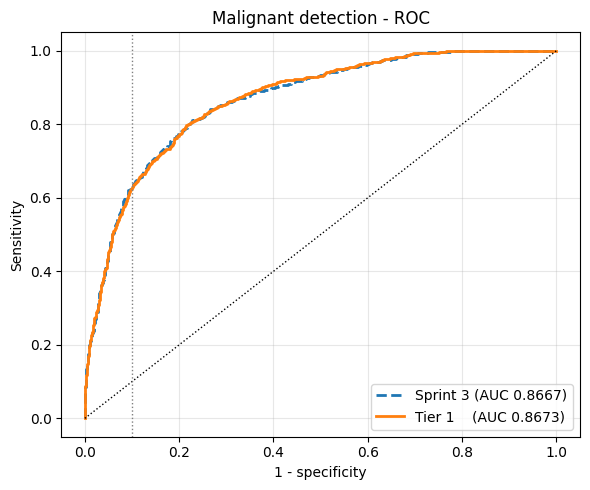

In [ ]:
def operating_points(probs, y, positive=MAL):
    y_bin = (y == positive).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, probs[:, positive])
    spec = 1 - fpr
    out = {}
    for ts in (0.80, 0.85, 0.90, 0.95):
        out[f'sens@spec{int(ts*100)}'] = tpr[np.argmin(np.abs(spec - ts))]
    for tn in (0.80, 0.85, 0.90, 0.95):
        out[f'spec@sens{int(tn*100)}'] = spec[np.argmin(np.abs(tpr - tn))]
    out['auc'] = roc_auc_score(y_bin, probs[:, positive])
    return out, (fpr, tpr)

op_base, (f0, t0) = operating_points(base_test, test_labels)
op_new,  (f1_, t1) = operating_points(test_ens, test_labels)

display(pd.DataFrame({'Sprint 3 baseline': op_base, 'Tier 1 tuned': op_new}).round(4))

plt.figure(figsize=(6, 5))
plt.plot(f0, t0, lw=2, ls='--', label=f"Sprint 3 (AUC {op_base['auc']:.4f})")
plt.plot(f1_, t1, lw=2,          label=f"Tier 1    (AUC {op_new['auc']:.4f})")
plt.plot([0, 1], [0, 1], 'k:', lw=1)
plt.axvline(0.10, color='grey', ls=':', lw=1)
plt.xlabel('1 - specificity'); plt.ylabel('Sensitivity')
plt.title('Malignant detection - ROC')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 12. Patient-level results

In [ ]:
def patient_agg(df, probs, labels):
    tmp = df.copy()
    tmp[['p_n', 'p_b', 'p_m']] = probs
    g = (tmp.groupby('source_subjectID')
            .agg(label=('label', 'max'), p_n=('p_n', 'mean'),
                 p_b=('p_b', 'mean'), p_m=('p_m', 'mean')).reset_index())
    return g[['p_n', 'p_b', 'p_m']].to_numpy(), g['label'].to_numpy()

pp_base, pl = patient_agg(test_df, base_test, test_labels)
pp_new,  _  = patient_agg(test_df, test_ens,  test_labels)

display(pd.DataFrame([
    evaluate(pp_base, pl, 'Sprint 3 baseline (patient)'),
    evaluate(pp_new,  pl, 'Tier 1 (patient)'),
    evaluate(pp_new,  pl, 'Tier 1 tuned (patient)', pred=(pp_new * COEF).argmax(1)),
]).set_index('model').round(4))

,accuracy,macro_f1,mal_recall,benign_f1,macro_auc
model,,,,,
Sprint 3 baseline (patient),0.7100,0.7106,0.7680,0.6264,0.8832
Tier 1 (patient),0.7088,0.7100,0.7813,0.6151,0.8777
Tier 1 tuned (patient),0.7196,0.7257,0.8000,0.6474,0.8777


## 13. Summary and save

In [ ]:
summary = pd.DataFrame([
    evaluate(base_test, test_labels, '1. Sprint 3 baseline (v4+v5+mammofm)'),
    evaluate(ens(test_probs, BEST_SUBSET), test_labels,
             f'2. Best subset equal ({"+".join(BEST_SUBSET)})'),
    evaluate(test_ens, test_labels, f'3. + weighting ({BEST_SCHEME})'),
    evaluate(test_ens, test_labels, '4. + tuned thresholds', pred=pred_tuned),
]).set_index('model').round(4)
display(summary)

d = summary.iloc[-1] - summary.iloc[0]
print('\nGAIN OVER SPRINT 3 BASELINE (percentage points)')
for k in ['accuracy', 'macro_f1', 'mal_recall', 'benign_f1', 'macro_auc']:
    print(f'  {k:12s} {100 * d[k]:+.2f}')

config = {'members': BEST_SUBSET,
          'weight_scheme': BEST_SCHEME,
          'weights': {k: float(v) for k, v in BEST_W.items()},
          'class_coef': COEF.tolist(),
          'tta': ['none', 'hflip', 'vflip', 'both'],
          'test_results': summary.iloc[-1].to_dict(),
          'operating_points': op_new}
with open(os.path.join(OUT_DIR, 'tier1_best_config.json'), 'w') as f:
    json.dump(config, f, indent=2, default=float)
summary.to_csv(os.path.join(OUT_DIR, 'tier1_summary.csv'))
np.savez_compressed(os.path.join(OUT_DIR, 'tier1_test_probs.npz'),
                    test_probs_ensemble=test_ens, test_labels=test_labels,
                    test_patient_ids=test_df['source_subjectID'].to_numpy(),
                    test_image_paths=test_df['image_path'].to_numpy(),
                    class_coef=COEF)
print('\nSaved to', OUT_DIR)

,accuracy,macro_f1,mal_recall,benign_f1,macro_auc
model,,,,,
1. Sprint 3 baseline (v4+v5+mammofm),0.7384,0.7390,0.7532,0.6285,0.8928
2. Best subset equal (v5+v6),0.7441,0.7445,0.7699,0.6287,0.8917
3. + weighting (macro_f1^4),0.7451,0.7457,0.7691,0.6312,0.8918
4. + tuned thresholds,0.7373,0.7415,0.7811,0.6340,0.8918



GAIN OVER SPRINT 3 BASELINE (percentage points)
  accuracy     -0.11
  macro_f1     +0.25
  mal_recall   +2.79
  benign_f1    +0.55
  macro_auc    -0.10

Saved to /content/drive/MyDrive/momobench-dataset/sprint4_tier1


## Next

If Tier 1 gained ground, the improved probabilities are saved as
`tier1_test_probs.npz` and can feed straight into the risk-inference pipeline.

Then Tier 2 — hierarchical binary cascade (Normal vs Abnormal, then Benign vs
Malignant), which the Mammo-Bench paper reports lifts Benign F1 from 0.45 to 0.72.